# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data

In [55]:
df_names_list = ['gdf_rho_0_1', 'gdf_rho_0_15', 'gdf_rho_0_2', 'gdf_rho_0_25', 'gdf_rho_0_3', 'gdf_rho_0_35', 'gdf_rho_0_4', 'gdf_rho_0_45', 'gdf_rho_0_5', 'gdf_rho_0_55']

In [56]:
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite'

In [58]:
dict_of_gdfs = {}
for i in df_names_list:
        gdf = import_spatial_point_data_frame(
                connection_link_lnx = repo_path_unix+"/03_simulated_data/simulated_data.sqlite",
                layer_name =i,
                crs_param = 3857
                                        )
        df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  f'{i}_sp'
                                        )
        df2 = df[['unit_id']+[c for c in df.columns.tolist() if 'spatial_predictor' in c]].copy()
        gdf2 = gdf.merge(df2, on = ['unit_id'])
        dict_of_gdfs[i] = gdf2

In [59]:
dict_of_gdfs["gdf_rho_0_1"].isna().any().any()

np.False_

In [60]:
dict_of_gdfs.keys()

dict_keys(['gdf_rho_0_1', 'gdf_rho_0_15', 'gdf_rho_0_2', 'gdf_rho_0_25', 'gdf_rho_0_3', 'gdf_rho_0_35', 'gdf_rho_0_4', 'gdf_rho_0_45', 'gdf_rho_0_5', 'gdf_rho_0_55'])

# Modelling causal inference

In [62]:
features_non_spatial = ['c1', 'c2']
list_of_effects_ik_dfs = []

for i in df_names_list:

    features_spatial = features_non_spatial+[c for c in dict_of_gdfs[i].columns.tolist() if 'spatial_predictor' in c]
    X_non_sp = dict_of_gdfs[i][features_non_spatial].values
    X_sp = dict_of_gdfs[i][features_spatial].values
    Y =  dict_of_gdfs[i]['y'].values
    T =  dict_of_gdfs[i]['t'].values

    dict_of_forests = {
        'cf_sp': X_sp,
        'cf_nsp': X_non_sp
    }
    gdf_temp = dict_of_gdfs[i].copy()
    list_of_effects_k_dfs = []
    for k in dict_of_forests.keys():
        est = CausalForestDML(model_t=RandomForestRegressor(),
                        model_y=RandomForestRegressor(),
                        n_estimators=180, #min_samples_leaf=5,
                        max_depth=10,
                        #verbose=0, 
                        random_state=42)
        est.fit(Y, T, X=dict_of_forests[k])
        tau_hat_cf = est.effect(dict_of_forests[k])
        gdf_temp[f'ITE_{k}'] = tau_hat_cf
        tau_hat_cf_treated = gdf_temp[gdf_temp['t']==1][f'ITE_{k}'].copy()
        att = tau_hat_cf_treated.mean()
        se_att = tau_hat_cf_treated.std(ddof=1) / np.sqrt(len(tau_hat_cf_treated))
        ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
        df_result_temp = pd.DataFrame({'model_name': [f'{k}'],'ci_low_att':[ci_low_att], 'att':[att], 'ci_high_att':[ci_high_att], 'rho': float('0.'+i[10:])})
        list_of_effects_k_dfs.append(df_result_temp)
    df_cf_att_i = pd.concat(list_of_effects_k_dfs)
    list_of_effects_ik_dfs.append(df_cf_att_i)
df_cf_att = pd.concat(list_of_effects_ik_dfs)

# Results visualization

In [65]:
df_cf_att

,model_name,ci_low_att,att,ci_high_att,rho
0,cf_sp,1.219789,1.315629,1.411469,0.10
0,cf_nsp,1.365703,1.460573,1.555443,0.10
0,cf_sp,1.032673,1.123710,1.214747,0.15
0,cf_nsp,1.379978,1.464226,1.548474,0.15
0,cf_sp,1.117870,1.192417,1.266964,0.20
0,cf_nsp,1.403087,1.491711,1.580335,0.20
0,cf_sp,1.095823,1.167348,1.238873,0.25
0,cf_nsp,1.540438,1.627154,1.713870,0.25
0,cf_sp,1.094513,1.186332,1.278151,0.30
0,cf_nsp,1.625371,1.713044,1.800716,0.30


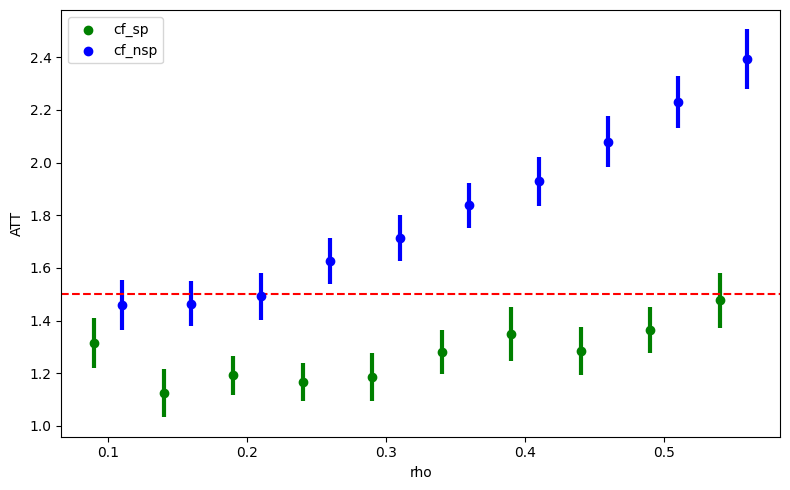

In [66]:
df_sp = df_cf_att[df_cf_att['model_name'] == 'cf_sp'].copy()
df_nsp = df_cf_att[df_cf_att['model_name'] == 'cf_nsp'].copy()

# lekkie przesunięcie na osi X
offset = 0.01
df_sp['rho_shift'] = df_sp['rho'] - offset
df_nsp['rho_shift'] = df_nsp['rho'] + offset

fig, ax = plt.subplots(figsize=(8, 5))

# --- cf_sp (zielony) ---
ax.scatter(df_sp['rho_shift'], df_sp['att'], color='green', label='cf_sp', zorder=3)

ax.vlines(
    x=df_sp['rho_shift'],
    ymin=df_sp['ci_low_att'],
    ymax=df_sp['ci_high_att'],
    color='green',
    linewidth=3
)

# --- cf_nsp (niebieski) ---
ax.scatter(df_nsp['rho_shift'], df_nsp['att'], color='blue', label='cf_nsp', zorder=3)

ax.vlines(
    x=df_nsp['rho_shift'],
    ymin=df_nsp['ci_low_att'],
    ymax=df_nsp['ci_high_att'],
    color='blue',
    linewidth=3
)

# pozioma linia odniesienia
ax.axhline(y=1.5, color='red', linestyle='--')

# opisy
ax.set_xlabel('rho')
ax.set_ylabel('ATT')
ax.legend()

plt.tight_layout()
plt.show()